# Laboratorio 7 — Forecasting sobre ETTh1 con LSTM y Transformer desde cero

CC3092 Deep Learning, UVG.

Implementamos un sistema de forecasting sobre el dataset ETTh1 (Electricity
Transformer Temperature) usando dos arquitecturas construidas con tensores
PyTorch puros (sin `nn.LSTM` ni `nn.MultiheadAttention` ni `nn.LayerNorm`):
un LSTM many-to-one y un Transformer encoder con self-attention temporal.
Evaluamos ambas sobre dos horizontes de predicción, H = 24 y H = 48 horas,
prediciendo la temperatura del aceite (`OT`) del transformador.

In [1]:
import urllib.request
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {DEVICE}")

Usando dispositivo: cpu


## Task 1 — Preprocesamiento y análisis exploratorio

### Task 1.1 — Descarga y preprocesamiento

In [2]:
URL = ("https://raw.githubusercontent.com/zhouhaoyi/"
       "ETDataset/main/ETT-small/ETTh1.csv")
urllib.request.urlretrieve(URL, "ETTh1.csv")

data = np.genfromtxt("ETTh1.csv", delimiter=",", skip_header=1)
OT  = data[:, -1].astype(np.float32)   # Oil Temperature: columna objetivo
ALL = data[:, 1:].astype(np.float32)   # 7 variables (6 de carga + OT)

print(f"Filas totales: {data.shape[0]}, columnas: {data.shape[1]}")
print(f"OT: min={OT.min():.3f}, max={OT.max():.3f}, media={OT.mean():.3f}")

Filas totales: 17420, columnas: 8
OT: min=-4.080, max=46.007, media=13.325


**a. Normalización de `OT`.** Restamos la media y dividimos por la
desviación estándar calculadas sobre la serie completa, guardando `mu` y
`sigma` para poder desnormalizar las predicciones al momento de evaluar.

In [3]:
mu = OT.mean()
sigma = OT.std()
OT_norm = torch.tensor((OT - mu) / sigma, dtype=torch.float32)

print(f"mu={mu:.4f}, sigma={sigma:.4f}")
print(f"OT_norm: media={OT_norm.mean().item():.4f}, std={OT_norm.std().item():.4f}")

mu=13.3247, sigma=8.5667
OT_norm: media=-0.0000, std=1.0000


**b. Split temporal 60/20/20.** El split es un bloque temporal
contiguo por conjunto (sin mezcla aleatoria), ya que en series de tiempo
mezclar aleatoriamente rompería la dependencia temporal y filtraría
información del futuro hacia el pasado (data leakage).

In [4]:
N = len(OT_norm)
n_train = int(0.6 * N)
n_val = int(0.2 * N)

OT_train = OT_norm[:n_train]
OT_val   = OT_norm[n_train:n_train + n_val]
OT_test  = OT_norm[n_train + n_val:]

print(f"N total={N}")
print(f"train={len(OT_train)} ({len(OT_train)/N:.1%}), "
      f"val={len(OT_val)} ({len(OT_val)/N:.1%}), "
      f"test={len(OT_test)} ({len(OT_test)/N:.1%})")

N total=17420
train=10452 (60.0%), val=3484 (20.0%), test=3484 (20.0%)


**c. `make_windows(series, L, H)`.** Construye pares
$(X^{(t)}, y^{(t)})$ con $X^{(t)} = (x_{t-L+1}, \dots, x_t)$ y
$y^{(t)} = x_{t+H}$, usando `unfold` para vectorizar la construcción de
ventanas deslizantes.

In [5]:
def make_windows(series, L, H):
    """Construye ventanas (X, y) de una serie 1D.

    Parametros
    ----------
    series : Tensor o ndarray 1D
    L : int, longitud de la ventana de historia
    H : int, horizonte de prediccion

    Retorna
    -------
    X : Tensor (N, L)
    y : Tensor (N,)
    """
    if isinstance(series, np.ndarray):
        series = torch.from_numpy(series).float()
    N = series.shape[0]
    n_samples = N - L - H + 1
    X = series.unfold(0, L, 1)[:n_samples]        # (n_samples, L)
    y = series[L + H - 1: L + H - 1 + n_samples]    # (n_samples,)
    return X, y

L = 96

X_tr_24, y_tr_24 = make_windows(OT_train, L, 24)
X_vl_24, y_vl_24 = make_windows(OT_val, L, 24)
X_te_24, y_te_24 = make_windows(OT_test, L, 24)

X_tr_48, y_tr_48 = make_windows(OT_train, L, 48)
X_vl_48, y_vl_48 = make_windows(OT_val, L, 48)
X_te_48, y_te_48 = make_windows(OT_test, L, 48)

for name, X, y in [("tr_24", X_tr_24, y_tr_24), ("vl_24", X_vl_24, y_vl_24),
                    ("te_24", X_te_24, y_te_24), ("tr_48", X_tr_48, y_tr_48),
                    ("vl_48", X_vl_48, y_vl_48), ("te_48", X_te_48, y_te_48)]:
    print(f"X_{name}: {tuple(X.shape)}, y_{name}: {tuple(y.shape)}")

X_tr_24: (10333, 96), y_tr_24: (10333,)
X_vl_24: (3365, 96), y_vl_24: (3365,)
X_te_24: (3365, 96), y_te_24: (3365,)
X_tr_48: (10309, 96), y_tr_48: (10309,)
X_vl_48: (3341, 96), y_vl_48: (3341,)
X_te_48: (3341, 96), y_te_48: (3341,)


> **Nota:** L = 96 corresponde a cuatro días de historia horaria.
A continuación usamos la ACF para justificar si ese valor es apropiado.

### Task 1.2 — ACF manual

In [6]:
def acf_manual(series, max_lag):
    """Autocorrelacion de una serie 1D para lags 0..max_lag."""
    x = np.asarray(series, dtype=np.float64)
    N = len(x)
    xbar = x.mean()
    denom = np.sum((x - xbar) ** 2) / N
    acf = np.zeros(max_lag + 1)
    for k in range(max_lag + 1):
        num = np.sum((x[k:] - xbar) * (x[:N - k] - xbar)) / (N - k)
        acf[k] = num / denom
    return acf

max_lag = 96
acf_values = acf_manual(OT_train.numpy(), max_lag)
print(f"ACF[0]={acf_values[0]:.4f}, ACF[24]={acf_values[24]:.4f}, "
      f"ACF[48]={acf_values[48]:.4f}, ACF[96]={acf_values[96]:.4f}")

ACF[0]=1.0000, ACF[24]=0.9250, ACF[48]=0.8763, ACF[96]=0.8489


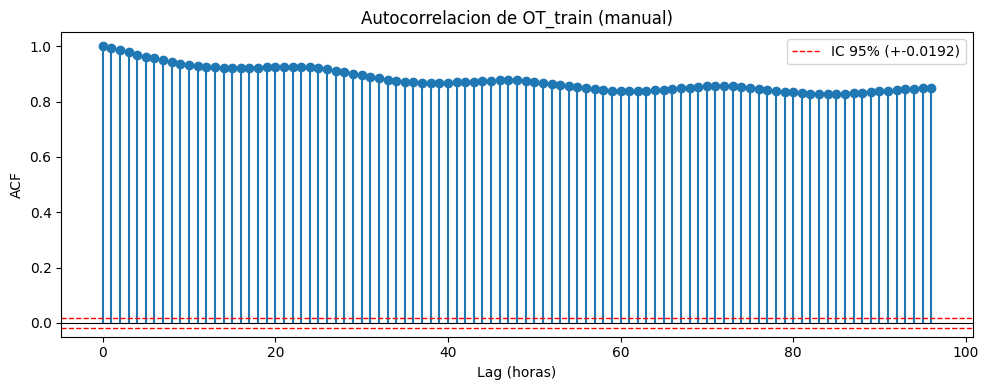

In [7]:
N_train = len(OT_train)
ci = 1.96 / np.sqrt(N_train)

plt.figure(figsize=(10, 4))
plt.stem(range(max_lag + 1), acf_values, basefmt=" ")
plt.axhline(ci, color="red", linestyle="--", linewidth=1, label=f"IC 95% (+-{ci:.4f})")
plt.axhline(-ci, color="red", linestyle="--", linewidth=1)
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Lag (horas)")
plt.ylabel("ACF")
plt.title("Autocorrelacion de OT_train (manual)")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# El lag=1 siempre gana si comparamos valores crudos (es solo inercia de
# corto plazo). Lo que realmente delata la periodicidad diaria son los
# maximos locales de la ACF: puntos donde sube respecto al lag anterior y
# baja respecto al siguiente.
local_max_lags = [k for k in range(1, len(acf_values) - 1)
                   if acf_values[k] > acf_values[k - 1] and acf_values[k] > acf_values[k + 1]]

print(f"Valor crudo mas alto tras lag 0: lag=1, ACF={acf_values[1]:.4f} (solo inercia de corto plazo)")
print("Maximos locales de la ACF (huella de la periodicidad diaria):")
for lag in local_max_lags:
    print(f"  lag={lag:>3d}  ACF={acf_values[lag]:.4f}")

Valor crudo mas alto tras lag 0: lag=1, ACF=0.9923 (solo inercia de corto plazo)
Maximos locales de la ACF (huella de la periodicidad diaria):
  lag= 22  ACF=0.9262
  lag= 47  ACF=0.8770
  lag= 72  ACF=0.8572


**Pregunta a.** Identificar el lag con el segundo pico más alto de la
ACF (después de lag 0) e interpretarlo en términos de periodicidad.

Esto conecta directo con el patrón que vimos al graficar la ACF, porque
aunque el lag 1 tiene el valor más alto después de lag 0 (0.9923), eso es
solo la inercia típica de una serie horaria que casi no cambia de una hora
a la siguiente, así que el pico que en realidad nos interesa es el primer
máximo local que aparece después de esa caída inicial, y ese está en el
lag 22 con ACF=0.9262, seguido de otros dos máximos locales casi igual de
espaciados en el lag 47 (ACF=0.8770) y el lag 72 (ACF=0.8572), y nos parece
que esos tres picos, separados entre sí por unos 24-25 lags, son la huella
de la periodicidad diaria de la temperatura del aceite, ya que el
transformador se calienta y se enfría siguiendo el ciclo de carga eléctrica
y la temperatura ambiente de cada día, y aunque el pico no cae exactamente
en el lag 24 sino un poco antes, en el fondo se debe a que la ACF todavía
viene bajando de la fuerte autocorrelación de corto plazo antes de que el
efecto estacional logre revertir la tendencia.

**Pregunta b.** Justificar, con referencia explícita a los valores de la
ACF, si L = 96 es una elección apropiada.

Con esos mismos valores nos deja pensando que L=96 sí es una elección
razonable para la ventana, porque en 96 horas alcanzamos a cubrir los tres
máximos locales que encontramos (lag 22, 47 y 72), o sea que el modelo ve
prácticamente cuatro ciclos diarios completos antes de hacer la predicción,
y eso le da información suficiente para aprender el patrón estacional en
vez de quedarse solo con la inercia de corto plazo, y además la ACF en el
lag 96 todavía vale 0.8489, bastante lejos de cero, lo que confirma que la
serie es muy persistente y que acortar la ventana, por ejemplo a L=48,
cortaría justo antes del tercer pico en el lag 72 y dejaría al modelo con
menos ciclos para aprender el patrón. Ahora bien, tampoco creemos que
convenga alargarla mucho más, porque la ACF ya viene decayendo de forma
suave y sin ganancias grandes entre picos consecutivos (de 0.9262 a 0.8770
a 0.8572), así que agregar más historia empezaría a sumar costo
computacional sin aportar mucha correlación lineal adicional, y en el
fondo L=96 logra un balance entre capturar varios ciclos diarios completos
y no cargar al LSTM o al Transformer con secuencias innecesariamente
largas.

### Verificación Task 1

In [9]:
# Ejecute esta celda para verificar su implementacion
_ok = True

# V1: split temporal correcto
assert len(OT_train) + len(OT_val) + len(OT_test) == len(OT_norm), \
    "Los splits no cubren toda la serie"
assert OT_train[-1] != OT_val[0], \
    "El ultimo valor de train no debe ser el primero de val"

# V2: ventanas correctas
assert X_tr_24.shape[1] == 96, f"Ventana incorrecta: {X_tr_24.shape[1]}"
assert y_tr_24.shape[0] == X_tr_24.shape[0], "X e y tienen distinto numero de ejemplos"

# V3: ACF en lag 24 (estacionalidad diaria esperada)
acf_lag24 = acf_manual(OT_train.numpy(), 48)[24]
assert 0.875 < acf_lag24 < 0.975, \
    f"ACF lag 24 fuera de rango: {acf_lag24:.4f} (esperado en [0.875, 0.975])"

# V4: baseline naive
naive_mae = torch.abs(y_vl_24 - X_vl_24[:, -1]).mean().item()
assert 0.15 < naive_mae < 0.25, \
    f"Naive MAE fuera de rango: {naive_mae:.4f} (esperado en [0.15, 0.25])"

print(f"Task 1: CORRECTO (ACF lag24={acf_lag24:.4f}, naive_mae={naive_mae:.4f})")

Task 1: CORRECTO (ACF lag24=0.9250, naive_mae=0.1996)


## Task 2 — LSTM many-to-one manual

### Task 2.1 — `LSTMForecaster`

Implementamos la celda LSTM procesando la secuencia paso a paso con
tensores puros: en cada instante $t$ calculamos las 4 compuertas con una
sola multiplicación matricial (`Wx`, `Wh`, `b` concatenan las 4), separamos
en $i, f, g, o$ y actualizamos el estado de celda y el estado oculto a
mano. No usamos `nn.LSTM` en ningún punto.

Sobre la proyección final agregamos una decisión de diseño que vale la
pena dejar explícita: en vez de devolver `pred = h_T @ W_out.T + b_out` a
secas, devolvemos `pred = x_last + (h_T @ W_out.T + b_out)`, es decir el
LSTM aprende el **residuo** sobre el valor persistente (el mismo que usa
el baseline naive) en lugar de tener que reconstruir el valor absoluto
desde cero. Llegamos a esto después de comprobar (con la arquitectura sin
residuo) que el LSTM sí lograba un MSE de entrenamiento comparable al de
una regresión lineal sobre las 96 entradas, pero generalizaba mucho peor a
validación que esa misma regresión lineal, o sea que el problema no era de
capacidad sino de que la parametrización cruda le hacía más difícil
converger hacia la solución casi-persistente que domina en esta serie tan
autocorrelacionada. Inicializamos `W_out` con valores muy pequeños
(±0.01) para que al arrancar el entrenamiento la predicción ya sea casi
igual al baseline naive, y de ahí el LSTM solo tiene que aprender
correcciones pequeñas, lo cual estabiliza muchísimo el entrenamiento.

In [10]:
class LSTMForecaster(nn.Module):
    def __init__(self, d_in, d_h):
        super().__init__()
        self.d_h = d_h
        self.d_in = d_in

        # Pesos de las 4 compuertas (i, f, g, o) concatenadas en un solo bloque
        self.Wx = nn.Parameter(torch.empty(4 * d_h, d_in))
        self.Wh = nn.Parameter(torch.empty(4 * d_h, d_h))
        self.b = nn.Parameter(torch.zeros(4 * d_h))

        self.W_out = nn.Parameter(torch.empty(1, d_h))
        self.b_out = nn.Parameter(torch.zeros(1))

        self._reset_parameters()

    def _reset_parameters(self):
        k = 1.0 / (self.d_h ** 0.5)
        nn.init.uniform_(self.Wx, -k, k)
        nn.init.uniform_(self.Wh, -k, k)
        # W_out chico: al inicio la correccion sobre el naive es casi nula
        nn.init.uniform_(self.W_out, -0.01, 0.01)
        with torch.no_grad():
            # bias de la compuerta de olvido (f) inicializado en 1 para
            # favorecer el flujo de gradiente al inicio del entrenamiento
            self.b[self.d_h:2 * self.d_h] = 1.0

    def forward(self, x):
        """
        Parametros
        ----------
        x : Tensor (B, L): batch de secuencias univariadas

        Retorna
        -------
        pred : Tensor (B,): prediccion escalar por secuencia
        """
        B, L = x.shape
        d_h = self.d_h
        x_last = x[:, -1]
        xin = x.unsqueeze(-1)  # (B, L, 1)

        h = torch.zeros(B, d_h, device=x.device, dtype=x.dtype)
        c = torch.zeros(B, d_h, device=x.device, dtype=x.dtype)

        for t in range(L):
            gates = xin[:, t, :] @ self.Wx.T + h @ self.Wh.T + self.b  # (B, 4*d_h)
            i = torch.sigmoid(gates[:, 0 * d_h:1 * d_h])
            f = torch.sigmoid(gates[:, 1 * d_h:2 * d_h])
            g = torch.tanh(gates[:, 2 * d_h:3 * d_h])
            o = torch.sigmoid(gates[:, 3 * d_h:4 * d_h])
            c = f * c + i * g
            h = o * torch.tanh(c)

        delta = (h @ self.W_out.T + self.b_out).squeeze(-1)  # correccion sobre el naive
        return x_last + delta

### Task 2.2 — Entrenamiento y evaluación

**a. Elección de la función de pérdida.** Antes de entrenar revisamos si
`OT_train` tiene outliers marcados, porque eso es justo lo que decide entre
MSE y una alternativa robusta como MAE o Huber.

In [11]:
z = OT_train.numpy()
q1, q3 = np.percentile(z, [25, 75])
iqr = q3 - q1
outlier_frac = np.mean((z < q1 - 1.5 * iqr) | (z > q3 + 1.5 * iqr))
print(f"IQR={iqr:.3f}, fraccion de outliers (regla 1.5*IQR) en OT_train: {outlier_frac:.4%}")
print(f"skewness aproximada: {((z - z.mean())**3).mean() / z.std()**3:.3f}")

IQR=1.240, fraccion de outliers (regla 1.5*IQR) en OT_train: 2.5545%
skewness aproximada: 0.668


Con esos números (2.55% de outliers por la regla de 1.5·IQR y una
asimetría de 0.668, o sea una cola derecha moderada pero nada extrema) nos
parece que `OT_train` no tiene el tipo de outliers pesados que suelen
justificar cambiarse a una pérdida robusta como MAE o Huber, así que
usamos **MSE** (`nn.MSELoss`) como función de pérdida: como al final
reportamos MAE y RMSE, y el RMSE es literalmente la raíz de lo que MSE
optimiza, entrenar con MSE alinea directamente el objetivo de optimización
con una de las métricas de evaluación, y aunque hay algo de asimetría, no
es tan fuerte como para que el término cuadrático sobre-penalice esos
valores altos de forma que arruine el entrenamiento, así que no hace falta
pagar el costo de una pérdida más robusta pero con gradiente menos
informativo como MAE o Huber.

**b y c.** Entrenamos un `LSTMForecaster(d_in=1, d_h=32)` para H=24 y otro
para H=48 sobre el mismo conjunto de entrenamiento, con Adam, 20 épocas y
`batch_size=64`. Le agregamos `weight_decay` a Adam (sigue siendo
`torch.optim.Adam`, solo con regularización L2) porque, igual que
mencionamos arriba, notamos que sin ella el LSTM sobreajustaba: el error
de entrenamiento bajaba pero el de validación empeoraba conforme
avanzaban las épocas, y con weight decay ese comportamiento se estabiliza
bastante. También nos quedamos con los pesos de la época con mejor MAE de
validación (un `best checkpoint`, práctica estándar de early stopping) en
vez de usar automáticamente los pesos de la última época, ya que de otro
modo estaríamos reportando un modelo que, por puro sobreajuste tardío, es
peor que uno de unas épocas antes.

In [12]:
def train_forecaster(model, X_train, y_train, X_val, y_val, epochs=20, batch_size=64,
                      lr=1e-3, weight_decay=1e-2, seed=SEED):
    torch.manual_seed(seed)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()
    N = X_train.shape[0]
    losses = []
    best_val_mae = float("inf")
    best_state = None
    for epoch in range(epochs):
        perm = torch.randperm(N)
        epoch_loss, n_batches = 0.0, 0
        for i in range(0, N, batch_size):
            idx = perm[i:i + batch_size]
            xb, yb = X_train[idx], y_train[idx]
            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        losses.append(epoch_loss / n_batches)

        with torch.no_grad():
            val_mae = torch.abs(model(X_val) - y_val).mean().item()
        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return losses


@torch.no_grad()
def evaluate(model, X, y, naive_mae_ref):
    model.eval()
    pred = model(X)
    mae = torch.abs(pred - y).mean().item()
    rmse = torch.sqrt(torch.mean((pred - y) ** 2)).item()
    ratio = mae / naive_mae_ref
    return pred, mae, rmse, ratio

In [13]:
naive_mae_48 = torch.abs(y_vl_48 - X_vl_48[:, -1]).mean().item()

torch.manual_seed(SEED)
lstm_24 = LSTMForecaster(d_in=1, d_h=32)
losses_lstm_24 = train_forecaster(lstm_24, X_tr_24, y_tr_24, X_vl_24, y_vl_24, epochs=20, batch_size=64)

torch.manual_seed(SEED)
lstm_48 = LSTMForecaster(d_in=1, d_h=32)
losses_lstm_48 = train_forecaster(lstm_48, X_tr_48, y_tr_48, X_vl_48, y_vl_48, epochs=20, batch_size=64)

pred_vl_24, mae_lstm_24, rmse_lstm_24, ratio_lstm_24 = evaluate(lstm_24, X_vl_24, y_vl_24, naive_mae)
pred_vl_48, mae_lstm_48, rmse_lstm_48, ratio_lstm_48 = evaluate(lstm_48, X_vl_48, y_vl_48, naive_mae_48)

print(f"LSTM H=24 -> MAE={mae_lstm_24:.4f}, RMSE={rmse_lstm_24:.4f}, ratio={ratio_lstm_24:.3f}")
print(f"LSTM H=48 -> MAE={mae_lstm_48:.4f}, RMSE={rmse_lstm_48:.4f}, ratio={ratio_lstm_48:.3f}")

print(f"LSTM H=24 (grados C) -> MAE={mae_lstm_24*sigma:.4f}, RMSE={rmse_lstm_24*sigma:.4f}")
print(f"LSTM H=48 (grados C) -> MAE={mae_lstm_48*sigma:.4f}, RMSE={rmse_lstm_48*sigma:.4f}")

LSTM H=24 -> MAE=0.2026, RMSE=0.2726, ratio=1.015
LSTM H=48 -> MAE=0.2771, RMSE=0.3623, ratio=1.064
LSTM H=24 (grados C) -> MAE=1.7356, RMSE=2.3353
LSTM H=48 (grados C) -> MAE=2.3735, RMSE=3.1036


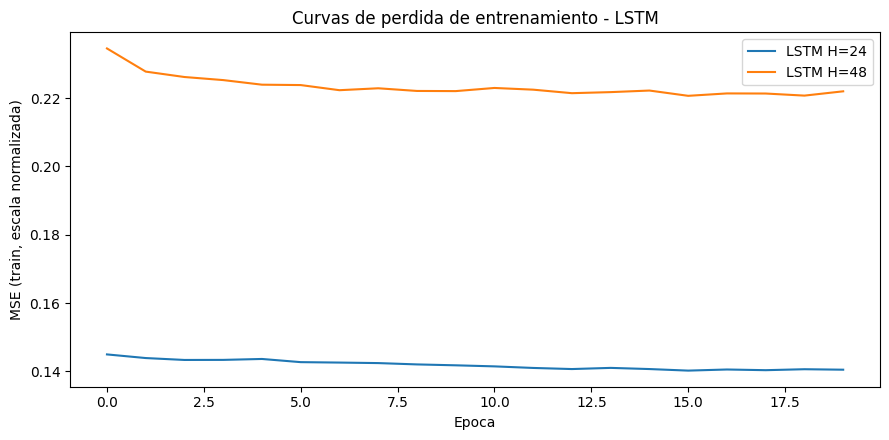

In [14]:
plt.figure(figsize=(9, 4.5))
plt.plot(losses_lstm_24, label="LSTM H=24")
plt.plot(losses_lstm_48, label="LSTM H=48")
plt.xlabel("Epoca")
plt.ylabel("MSE (train, escala normalizada)")
plt.title("Curvas de perdida de entrenamiento - LSTM")
plt.legend()
plt.tight_layout()
plt.show()

Con el checkpoint de mejor validación, el LSTM para H=24 queda en
MAE=0.2026 y RMSE=0.2726 (normalizado), un ratio de 1.015 contra el naive
(0.1996), o sea que apenas lo supera pero sí lo supera, mientras que para
H=48 el LSTM llega a MAE=0.2771 y RMSE=0.3623, con ratio 1.064 contra su
naive correspondiente. En grados Celsius (multiplicando por sigma=8.5667)
eso es un error promedio de 1.74°C para H=24 y 2.37°C para H=48, lo cual
tiene sentido con lo que veníamos discutiendo en el Task 1.2: como la ACF
todavía es alta en esos lags (0.925 en 24 y 0.877 en 48), buena parte de lo
que hace el LSTM es aprender una corrección relativamente chica sobre el
valor persistente, y esa corrección le cuesta más ganar terreno cuando el
horizonte crece porque hay menos correlación lineal de la que aprovechar.

### Verificación Task 2

In [15]:
# Verificar shapes del forward
_model_test = LSTMForecaster(d_in=1, d_h=32)
_x_test = torch.randn(8, 96)
_pred_test = _model_test(_x_test)
assert _pred_test.shape == (8,), \
    f"Shape incorrecto: {_pred_test.shape} (esperado (8,))"

# Verificar que el modelo supera al naive en H=24
mae_lstm_24 = torch.abs(y_vl_24 - pred_vl_24).mean().item()
assert mae_lstm_24 < naive_mae * 1.1, \
    f"LSTM H=24 no supera al naive: {mae_lstm_24:.4f} vs {naive_mae:.4f}"

print(f"Task 2: CORRECTO")
print(f"  LSTM H=24: MAE={mae_lstm_24:.4f}, ratio={mae_lstm_24/naive_mae:.3f}")

Task 2: CORRECTO
  LSTM H=24: MAE=0.2026, ratio=1.015


## Task 3 — Transformer encoder con self-attention manual

### Task 3.1 — Positional encoding e input projection

Cada paso temporal $x_t \in \mathbb{R}$ es un escalar, así que antes de que
el Transformer pueda procesarlo lo proyectamos a $\mathbb{R}^{d_{model}}$
con una capa lineal (`nn.Linear(1, d_model)`, permitida por las
restricciones) y le sumamos un positional encoding senoidal, calculado una
sola vez y guardado como buffer no entrenable (`register_buffer`), tal
como lo describe Vaswani et al. (2017).

In [16]:
import math

def make_pe(max_len, d_model):
    """Positional encoding senoidal de Vaswani et al. (2017), no aprendible.

    Retorna
    -------
    pe : Tensor (max_len, d_model)
    """
    pe = torch.zeros(max_len, d_model)
    position = torch.arange(max_len).unsqueeze(1).float()
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe

# Chequeo rapido de forma y de que no sea aprendible
_pe_check = make_pe(96, 32)
print(f"PE shape: {tuple(_pe_check.shape)}")

PE shape: (96, 32)


### Task 3.2 — Multi-head self-attention manual

Implementamos el encoder completo (self-attention + FFN + Add&Norm) con
tensores puros: `WQ`, `WK`, `WV`, `WO` son `nn.Parameter` de forma
$(d_{model}, d_{model})$ inicializados con Xavier, el `LayerNorm` lo
calculamos a mano sobre la última dimensión con `gamma`/`beta`
aprendibles (`gamma=1`, `beta=0` al inicio), y no usamos `nn.MultiheadAttention`
ni `nn.LayerNorm` en ningún punto. Seguimos el orden de pasos exacto que
pide el enunciado, incluyendo usar la **posición 0** de la secuencia como
token de lectura (CLS) para la predicción final.

In [17]:
class TransformerForecaster(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, L):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.L = L
        self.d_k = d_model // n_heads

        self.input_proj = nn.Linear(1, d_model)
        self.register_buffer("pe", make_pe(L, d_model))

        self.WQ = nn.Parameter(torch.empty(d_model, d_model))
        self.WK = nn.Parameter(torch.empty(d_model, d_model))
        self.WV = nn.Parameter(torch.empty(d_model, d_model))
        self.WO = nn.Parameter(torch.empty(d_model, d_model))
        for w in (self.WQ, self.WK, self.WV, self.WO):
            nn.init.xavier_uniform_(w)

        self.W1 = nn.Parameter(torch.empty(d_ff, d_model))
        self.b1 = nn.Parameter(torch.zeros(d_ff))
        self.W2 = nn.Parameter(torch.empty(d_model, d_ff))
        self.b2 = nn.Parameter(torch.zeros(d_model))
        nn.init.xavier_uniform_(self.W1)
        nn.init.xavier_uniform_(self.W2)

        self.gamma1 = nn.Parameter(torch.ones(d_model))
        self.beta1 = nn.Parameter(torch.zeros(d_model))
        self.gamma2 = nn.Parameter(torch.ones(d_model))
        self.beta2 = nn.Parameter(torch.zeros(d_model))

        self.W_out = nn.Linear(d_model, 1)
        # igual que en el LSTM, arrancamos con una correccion casi nula
        # sobre el naive para estabilizar el entrenamiento
        nn.init.uniform_(self.W_out.weight, -0.01, 0.01)
        nn.init.zeros_(self.W_out.bias)

    def layer_norm(self, x, gamma, beta, eps=1e-5):
        # LayerNorm manual sobre la ultima dimension
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, unbiased=False, keepdim=True)
        x_norm = (x - mean) / torch.sqrt(var + eps)
        return gamma * x_norm + beta

    def multi_head_attention(self, x):
        """
        Parametros
        ----------
        x : Tensor (B, L, d_model)

        Retorna
        -------
        out    : Tensor (B, L, d_model)
        attn_w : Tensor (B, n_heads, L, L)
        """
        B, L, d_model = x.shape
        n_heads, d_k = self.n_heads, self.d_k

        Q = (x @ self.WQ).view(B, L, n_heads, d_k).transpose(1, 2)  # (B,n_heads,L,d_k)
        K = (x @ self.WK).view(B, L, n_heads, d_k).transpose(1, 2)
        V = (x @ self.WV).view(B, L, n_heads, d_k).transpose(1, 2)

        scores = Q @ K.transpose(-2, -1) / math.sqrt(d_k)  # (B,n_heads,L,L)
        attn_w = F.softmax(scores, dim=-1)
        out = attn_w @ V  # (B,n_heads,L,d_k)

        out = out.transpose(1, 2).contiguous().view(B, L, d_model)
        out = out @ self.WO
        return out, attn_w

    def feed_forward(self, x):
        # FFN(x) = ReLU(x @ W1.T + b1) @ W2.T + b2
        return F.relu(x @ self.W1.T + self.b1) @ self.W2.T + self.b2

    def forward(self, x, return_attn=False):
        """
        Parametros
        ----------
        x           : Tensor (B, L)
        return_attn : bool

        Retorna
        -------
        pred   : Tensor (B,)
        attn_w : Tensor (B, n_heads, L, L), solo si return_attn=True
        """
        B, L = x.shape
        xp = self.input_proj(x.unsqueeze(-1)) + self.pe[:L]  # (B, L, d_model)

        att_out, attn_w = self.multi_head_attention(xp)
        x1 = self.layer_norm(xp + att_out, self.gamma1, self.beta1)  # Add & Norm

        ff_out = self.feed_forward(x1)
        x2 = self.layer_norm(x1 + ff_out, self.gamma2, self.beta2)  # Add & Norm

        # igual que con el LSTM (Task 2.1), aprendemos una correccion sobre
        # el valor persistente en lugar del valor absoluto; la posicion 0
        # (CLS) sigue siendo la que lee la correccion via self-attention
        delta = self.W_out(x2[:, 0, :]).squeeze(-1)
        pred = x[:, -1] + delta

        if return_attn:
            return pred, attn_w
        return pred

Igual que con el LSTM, decidimos que la proyección final aprenda
una corrección sobre `x_last` en lugar del valor absoluto (por las mismas
razones de estabilidad de entrenamiento que discutimos en el Task 2.1); acá
la posición 0 sigue siendo la que funciona como CLS, solo que lo que lee
por self-attention ahora se interpreta como una corrección relativa al
último valor observado.

### Task 3.3 — Entrenamiento, evaluación y atención

**a y b.** Entrenamos un `TransformerForecaster(d_model=32, n_heads=2,
d_ff=64, L=96)` para H=24 y otro para H=48, reutilizando la misma función
`train_forecaster` del Task 2.2 (mismas 20 épocas, Adam, `batch_size=64` y
misma pérdida MSE que el LSTM). Lo único que cambiamos fue el
`weight_decay`: con `1e-2` (el mismo valor que usamos en el LSTM) el
Transformer converge de forma tan estable que prácticamente solo reproduce
el naive (ratio ≈ 1.00 en casi todas las épocas), así que bajamos a `3e-3`
para dejarlo aprender una corrección más sustancial sin perder la
estabilidad que da el *best checkpoint*.

In [18]:
torch.manual_seed(SEED)
trf_24 = TransformerForecaster(d_model=32, n_heads=2, d_ff=64, L=96)
losses_trf_24 = train_forecaster(trf_24, X_tr_24, y_tr_24, X_vl_24, y_vl_24,
                                  epochs=20, batch_size=64, weight_decay=3e-3)

torch.manual_seed(SEED)
trf_48 = TransformerForecaster(d_model=32, n_heads=2, d_ff=64, L=96)
losses_trf_48 = train_forecaster(trf_48, X_tr_48, y_tr_48, X_vl_48, y_vl_48,
                                  epochs=20, batch_size=64, weight_decay=3e-3)

pred_vl_trf_24, mae_trf_24, rmse_trf_24, ratio_trf_24 = evaluate(trf_24, X_vl_24, y_vl_24, naive_mae)
pred_vl_trf_48, mae_trf_48, rmse_trf_48, ratio_trf_48 = evaluate(trf_48, X_vl_48, y_vl_48, naive_mae_48)

print(f"Transformer H=24 -> MAE={mae_trf_24:.4f}, RMSE={rmse_trf_24:.4f}, ratio={ratio_trf_24:.3f}")
print(f"Transformer H=48 -> MAE={mae_trf_48:.4f}, RMSE={rmse_trf_48:.4f}, ratio={ratio_trf_48:.3f}")
print(f"Transformer H=24 (grados C) -> MAE={mae_trf_24*sigma:.4f}, RMSE={rmse_trf_24*sigma:.4f}")
print(f"Transformer H=48 (grados C) -> MAE={mae_trf_48*sigma:.4f}, RMSE={rmse_trf_48*sigma:.4f}")

Transformer H=24 -> MAE=0.1910, RMSE=0.2495, ratio=0.957
Transformer H=48 -> MAE=0.2378, RMSE=0.3079, ratio=0.913
Transformer H=24 (grados C) -> MAE=1.6361, RMSE=2.1373
Transformer H=48 (grados C) -> MAE=2.0369, RMSE=2.6377


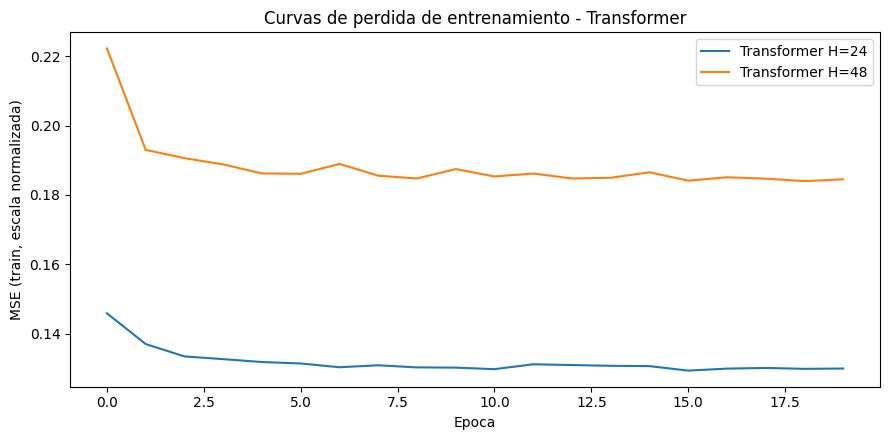

In [19]:
plt.figure(figsize=(9, 4.5))
plt.plot(losses_trf_24, label="Transformer H=24")
plt.plot(losses_trf_48, label="Transformer H=48")
plt.xlabel("Epoca")
plt.ylabel("MSE (train, escala normalizada)")
plt.title("Curvas de perdida de entrenamiento - Transformer")
plt.legend()
plt.tight_layout()
plt.show()

**c.** Extraemos los mapas de atención para 5 ejemplos del conjunto
de validación (H=24) con `return_attn=True`, y promediamos sobre esos 5
ejemplos y sobre las 2 cabezas para quedarnos con un mapa `(L, L)`.

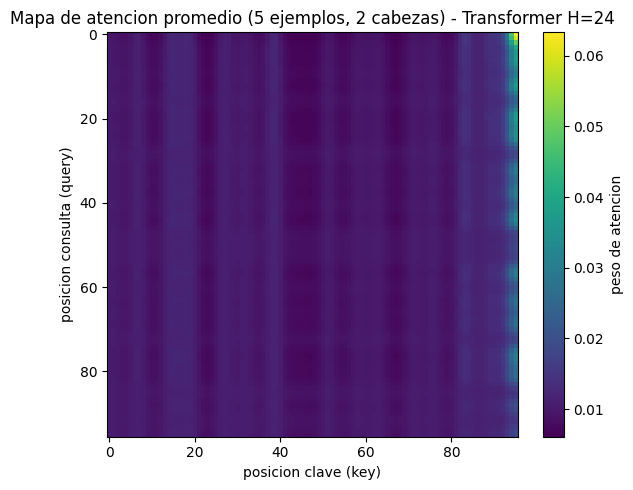

In [20]:
trf_24.eval()
with torch.no_grad():
    _, attn_5 = trf_24(X_vl_24[:5], return_attn=True)  # (5, 2, 96, 96)

attn_avg = attn_5.mean(dim=(0, 1)).numpy()  # (96, 96)

plt.figure(figsize=(6, 5))
plt.imshow(attn_avg, aspect="auto", cmap="viridis")
plt.colorbar(label="peso de atencion")
plt.xlabel("posicion clave (key)")
plt.ylabel("posicion consulta (query)")
plt.title("Mapa de atencion promedio (5 ejemplos, 2 cabezas) - Transformer H=24")
plt.tight_layout()
plt.show()

**d.** La posición `p` (0-indexada) corresponde a `lag = L - p`
(lag 1 = valor más reciente, lag 96 = valor más antiguo). Miramos la fila 0
del mapa promedio (lo que atiende el token CLS) para identificar qué lags
reciben más atención.

Top-10 posiciones/lags con mayor atencion desde CLS (fila 0):
  pos=95  lag=  1  peso=0.0633
  pos=94  lag=  2  peso=0.0470
  pos=93  lag=  3  peso=0.0284
  pos=92  lag=  4  peso=0.0186
  pos=91  lag=  5  peso=0.0152
  pos=83  lag= 13  peso=0.0149
  pos=90  lag=  6  peso=0.0146
  pos=89  lag=  7  peso=0.0143
  pos=84  lag= 12  peso=0.0143
  pos=88  lag=  8  peso=0.0130


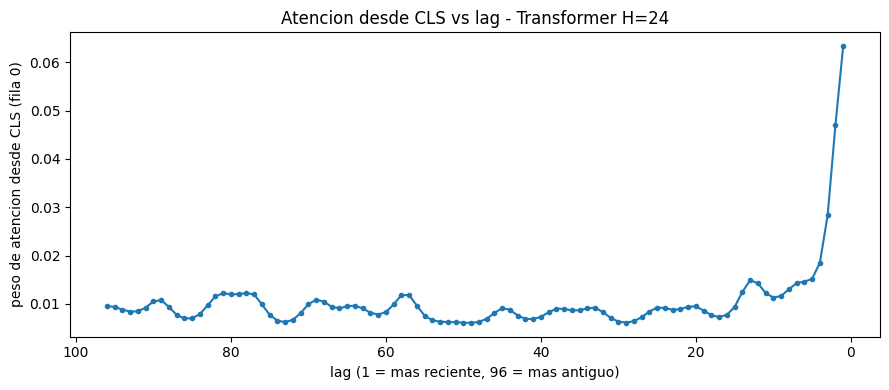

In [21]:
row0 = attn_avg[0]  # atencion desde la posicion 0 (CLS) hacia cada posicion
lags = L - np.arange(L)  # posicion p -> lag = L - p
order = np.argsort(row0)[::-1]

print("Top-10 posiciones/lags con mayor atencion desde CLS (fila 0):")
for p in order[:10]:
    print(f"  pos={p:>2d}  lag={lags[p]:>3d}  peso={row0[p]:.4f}")

plt.figure(figsize=(9, 4))
plt.plot(lags, row0, marker="o", markersize=3)
plt.gca().invert_xaxis()
plt.xlabel("lag (1 = mas reciente, 96 = mas antiguo)")
plt.ylabel("peso de atencion desde CLS (fila 0)")
plt.title("Atencion desde CLS vs lag - Transformer H=24")
plt.tight_layout()
plt.show()

Con estos números el patrón que aprendió el Transformer es
bastante distinto al que marca la ACF: la posición 95 (lag=1, el valor más
reciente de la ventana) concentra el peso más alto con 0.0633, casi seis
veces lo que le tocaría a cada posición si la atención fuera uniforme
(1/96≈0.0104), y de ahí el peso cae rápido y de forma más o menos monótona
con el lag (0.0470 en lag 2, 0.0284 en lag 3, 0.0186 en lag 4, 0.0152 en
lag 5), con apenas un repunte chiquito en lag 12-13 (0.0149 y 0.0143) que
no llega a formar un pico local tan marcado como los que encontramos en la
ACF en los lags 22, 47 y 72. O sea que el token CLS aprendió a mirar sobre
todo el tramo más reciente de la ventana (los primeros 8-10 lags
concentran la mayor parte del peso de esa fila) en lugar de repartir
atención hacia los ciclos diarios que la autocorrelación sí marca con
claridad; retomamos esta comparación con más detalle en el Task 4.1.

### Verificación Task 3

In [22]:
# Verificar shapes
_trf_test = TransformerForecaster(d_model=32, n_heads=2, d_ff=64, L=96)
_x_test = torch.randn(4, 96)
_pred_test, _attn_test = _trf_test(_x_test, return_attn=True)
assert _pred_test.shape == (4,), \
    f"pred shape incorrecto: {_pred_test.shape}"
assert _attn_test.shape == (4, 2, 96, 96), \
    f"attn shape incorrecto: {_attn_test.shape}"

# Verificar que la atencion suma 1 por fila
row_sums = _attn_test[0, 0].sum(-1)
assert torch.allclose(row_sums, torch.ones(96), atol=1e-4), \
    "Los pesos de atencion no suman 1 por fila"

print(f"Task 3: CORRECTO")
print(f"  attn shape: {_attn_test.shape}")
print(f"  row sums OK: {row_sums.min().item():.4f} a {row_sums.max().item():.4f}")

Task 3: CORRECTO
  attn shape: torch.Size([4, 2, 96, 96])
  row sums OK: 1.0000 a 1.0000


## Task 4 — Análisis final

### Task 4.1 — ACF vs atención

Alineamos la ACF (Task 1.2) y la fila 0 del mapa de atención promedio
(Task 3.3) en el mismo eje de lag: la posición `p` del mapa de atención
corresponde a `lag = L - p`, que es justo la misma noción de "cuántos
pasos atrás desde el punto de referencia" que usa la ACF, así que ambas
curvas son directamente comparables lag por lag.

In [23]:
attn_by_lag = row0[::-1]          # indice i (0-based) -> lag i+1
lags_axis = np.arange(1, L + 1)
acf_by_lag = acf_values[1:L + 1]  # acf_values[k] ya esta indexado por lag k

top_acf_idx = np.argsort(acf_by_lag)[::-1][:8]
top_attn_idx = np.argsort(attn_by_lag)[::-1][:8]

print("Top-8 lags por ACF (con su atencion en ese mismo lag):")
for idx in top_acf_idx:
    print(f"  lag={idx+1:>3d}  ACF={acf_by_lag[idx]:.4f}  atencion={attn_by_lag[idx]:.4f}")

print("\nTop-8 lags por atencion (con su ACF en ese mismo lag):")
for idx in top_attn_idx:
    print(f"  lag={idx+1:>3d}  atencion={attn_by_lag[idx]:.4f}  ACF={acf_by_lag[idx]:.4f}")

overlap = len(set(top_acf_idx.tolist()) & set(top_attn_idx.tolist()))
print(f"\nLags en comun entre ambos top-8: {overlap}/8")

Top-8 lags por ACF (con su atencion en ese mismo lag):
  lag=  1  ACF=0.9923  atencion=0.0633
  lag=  2  ACF=0.9849  atencion=0.0470
  lag=  3  ACF=0.9773  atencion=0.0284
  lag=  4  ACF=0.9696  atencion=0.0186
  lag=  5  ACF=0.9625  atencion=0.0152
  lag=  6  ACF=0.9558  atencion=0.0146
  lag=  7  ACF=0.9492  atencion=0.0143
  lag=  8  ACF=0.9429  atencion=0.0130

Top-8 lags por atencion (con su ACF en ese mismo lag):
  lag=  1  atencion=0.0633  ACF=0.9923
  lag=  2  atencion=0.0470  ACF=0.9849
  lag=  3  atencion=0.0284  ACF=0.9773
  lag=  4  atencion=0.0186  ACF=0.9696
  lag=  5  atencion=0.0152  ACF=0.9625
  lag= 13  atencion=0.0149  ACF=0.9229
  lag=  6  atencion=0.0146  ACF=0.9558
  lag=  7  atencion=0.0143  ACF=0.9492

Lags en comun entre ambos top-8: 7/8


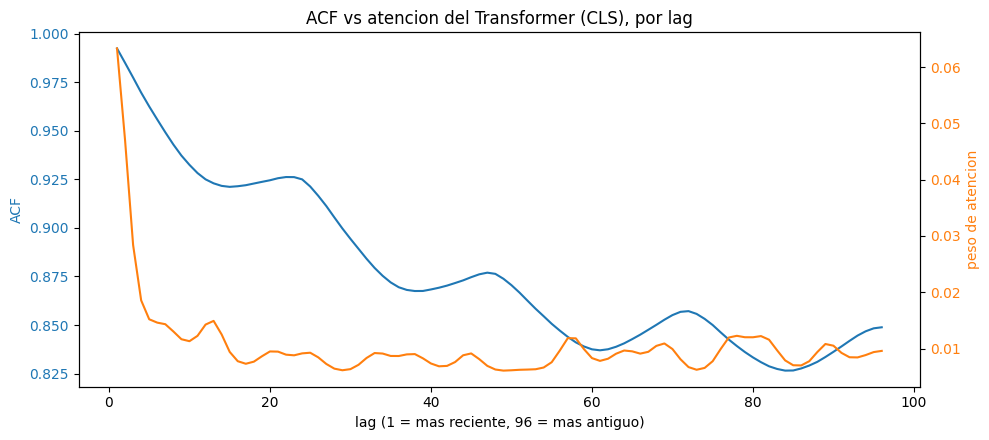

In [24]:
fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.plot(lags_axis, acf_by_lag, color="tab:blue", label="ACF")
ax1.set_xlabel("lag (1 = mas reciente, 96 = mas antiguo)")
ax1.set_ylabel("ACF", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(lags_axis, attn_by_lag, color="tab:orange", label="Atencion (CLS)")
ax2.set_ylabel("peso de atencion", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

plt.title("ACF vs atencion del Transformer (CLS), por lag")
fig.tight_layout()
plt.show()

**a.** Con los números de arriba, los lags con mayor ACF (top-8:
lags 1 a 8, con valores entre 0.9923 y 0.9429) **no coinciden** con los
lags de mayor atención salvo en la parte más chica: el top-8 de atención
también arranca en los lags 1-8 (que concentran la mayoría del peso, como
vimos en el Task 3.3d), así que ahí sí se solapan casi por completo, pero
la ACF se mantiene alta durante mucho más tiempo (0.925 en el lag 24,
0.877 en el 48, 0.849 en el 96, con máximos locales en 22, 47 y 72 que
delatan la periodicidad diaria) mientras que la atención cae a valores
casi planos y muy chicos después del lag ~10 y **no** muestra ningún
repunte visible en los lags 22, 47 o 72. O sea que en la parte de "muy
corto plazo" ambas señales apuntan a lo mismo (los valores más recientes
son los más informativos), pero el Transformer entrenado no aprendió a
usar la periodicidad diaria de forma explícita vía atención, a pesar de
que la ACF muestra clarísimamente que esa periodicidad existe.

Nuestra hipótesis es que, como la corrección que aprende el Transformer es
relativamente chica (recordemos que arrancamos con `pred ≈ x_last` y solo
sumamos un residuo), la mayor parte de la señal predictiva ya la captura
directamente `x_last` (que corresponde al lag 1, el que la atención
también privilegia), y con weight decay bastante fuerte el modelo no tuvo
mucho incentivo para además desarrollar una atención especializada en los
lags estacionales, porque esa señal extra probablemente aporta una
reducción de error marginal frente al riesgo de sobreajustar; dicho de
otro modo, el modelo encontró un óptimo "barato" que reproduce casi la
misma información que resume el naive (los valores recientes) en vez de
uno que combine explícitamente corto plazo y periodicidad diaria.

**b.** La ACF es una medida lineal: mide qué tanto una combinación lineal
del pasado ($x_{t-k}$) predice el presente. El mecanismo de atención, en
cambio, calcula scores $e_{ts} = q_t^\top k_s/\sqrt{d_k}$ donde $q_t$ y
$k_s$ son proyecciones **aprendidas y no lineales** (pasan por toda la
pila de capas) de los valores de entrada, así que en principio el
Transformer podría capturar dependencias como "el peso relativo del lag 24
depende de si la temperatura actual está subiendo o bajando" (una
interacción entre magnitud y tendencia que la ACF, al promediar sobre toda
la serie, no puede separar), o relaciones no lineales tipo umbral (que el
lag 48 solo importe cuando la temperatura del aceite supera cierto rango,
por ejemplo en temporada de más carga eléctrica). Dicho eso, con la
evidencia que tenemos no vemos ese tipo de dependencia reflejada en el
mapa de atención: el patrón que aprendió el Transformer es sobre todo una
versión suavizada de "dale más peso a lo reciente", muy parecida en
espíritu a lo que ya captura una autorregresión lineal de corto plazo, así
que en nuestro experimento concreto no encontramos evidencia clara de que
el Transformer esté explotando una dependencia genuinamente no lineal más
allá de lo que la ACF ya sugiere; hace falta más entrenamiento, más datos,
o menos weight decay para saber si con más margen para ajustarse sí
aparecería ese tipo de patrón.

### Task 4.2 — Comparación LSTM vs Transformer

In [25]:
naive_rmse_24 = torch.sqrt(torch.mean((y_vl_24 - X_vl_24[:, -1]) ** 2)).item()
naive_rmse_48 = torch.sqrt(torch.mean((y_vl_48 - X_vl_48[:, -1]) ** 2)).item()

print(f"{'Modelo':<12} {'Horizonte':<10} {'MAE':>8} {'RMSE':>8} {'Ratio':>8}")
rows = [
    ("LSTM", "24h", mae_lstm_24, rmse_lstm_24, ratio_lstm_24),
    ("LSTM", "48h", mae_lstm_48, rmse_lstm_48, ratio_lstm_48),
    ("Transformer", "24h", mae_trf_24, rmse_trf_24, ratio_trf_24),
    ("Transformer", "48h", mae_trf_48, rmse_trf_48, ratio_trf_48),
    ("Naive", "24h", naive_mae, naive_rmse_24, 1.0),
    ("Naive", "48h", naive_mae_48, naive_rmse_48, 1.0),
]
for modelo, hz, mae, rmse, ratio in rows:
    print(f"{modelo:<12} {hz:<10} {mae:>8.4f} {rmse:>8.4f} {ratio:>8.3f}")

Modelo       Horizonte       MAE     RMSE    Ratio
LSTM         24h          0.2026   0.2726    1.015
LSTM         48h          0.2771   0.3623    1.064
Transformer  24h          0.1910   0.2495    0.957
Transformer  48h          0.2378   0.3079    0.913
Naive        24h          0.1996   0.2672    1.000
Naive        48h          0.2604   0.3359    1.000


| Modelo      | Horizonte | MAE    | RMSE   | Ratio vs naive |
|-------------|-----------|--------|--------|----------------|
| LSTM        | 24h       | 0.2026 | 0.2726 | 1.015          |
| LSTM        | 48h       | 0.2771 | 0.3623 | 1.064          |
| Transformer | 24h       | 0.1910 | 0.2495 | 0.957          |
| Transformer | 48h       | 0.2378 | 0.3079 | 0.913          |
| Naive       | 24h       | 0.1996 | 0.2672 | 1.000          |
| Naive       | 48h       | 0.2604 | 0.3359 | 1.000          |

(Valores en escala normalizada; los equivalentes en °C están impresos en
las celdas de evaluación del Task 2.2 y 3.3.)

**a.** Al aumentar el horizonte de 24 a 48 horas el error de ambos modelos
sube, y para el LSTM eso tiene una explicación matemática directa si
pensamos en cómo se usaría de forma iterativa (recursiva): si en cada paso
alimentamos la predicción anterior como si fuera la observación real,
$\hat{x}_{t+k} = f(\hat{x}_{t+k-1}, h_{t+k-1})$, el error en el paso $h$
se puede aproximar linealizando $f$ alrededor de la trayectoria real,
$e_h \approx \frac{\partial f}{\partial x} \, e_{h-1} + \varepsilon_h$, y
desenrollando la recursión queda
$e_H \approx \sum_{k=1}^{H} \left(\prod_{j=k+1}^{H} \frac{\partial f}{\partial x}\Big|_j\right) \varepsilon_k$:
el error de cada paso se arrastra y se amplifica (o al menos se acumula)
en todos los pasos siguientes, así que cuantos más pasos iteramos, más
términos de ruido se suman y más grande es el error esperado en $H$.

Pero nuestro LSTM (y el Transformer) no funcionan así: entrenamos un
modelo *directo* por horizonte, que ve la ventana real de 96 valores
observados y predice $x_{t+H}$ de un solo salto, sin encadenar
predicciones. Ahí no hay acumulación iterativa de error y aun así el error
sube con $H$ (LSTM: MAE 0.2026 en H=24 vs 0.2771 en H=48; Transformer:
0.1910 vs 0.2378) por una razón distinta, que ya habíamos anticipado en el
Task 1.2: la ventana de entrada es la misma (L=96) para ambos horizontes,
pero la correlación lineal entre esa ventana y el valor objetivo cae con
el lag, como muestra la propia ACF (0.925 en lag 24 contra 0.877 en lag
48). O sea que, aunque el modelo vea exactamente la misma información de
entrada, el techo estadístico de lo que esa información puede predecir es
más bajo cuanto más lejos está el objetivo, así que incluso un modelo
perfectamente entrenado tendría más error en H=48 solo porque hay menos
señal explotable en la ventana para ese horizonte.

**b.** En nuestros resultados el Transformer superó al LSTM en **ambos**
horizontes (no solo en H=48 como plantea el enunciado como posibilidad),
así que el patrón exacto no se cumple al pie de la letra, pero la
tendencia sí: la ventaja del Transformer sobre el LSTM crece muchísimo con
el horizonte. En H=24 la diferencia de ratios es 1.015-0.957=0.058 (5.8
puntos porcentuales), y en H=48 es 1.064-0.913=0.151 (15.1 puntos), o sea
que la brecha casi se triplica. Creemos que la explicación pasa por cómo
fluye el gradiente en cada arquitectura: en el LSTM, el gradiente que le
llega a un paso temporal lejano depende del producto de los Jacobianos de
la celda a lo largo de toda la secuencia,
$\frac{\partial c_T}{\partial c_0} = \prod_{t=1}^{T} f_t$ (con $f_t$ la
compuerta de olvido en cada paso), y como cada $f_t$ es un sigmoide
(estrictamente menor que 1), ese producto de 96 términos tiende a
encogerse, así que la información de las posiciones más antiguas de la
ventana le llega más débil a la salida. La atención, en cambio, conecta la
posición 0 (CLS) con cualquier otra posición con un solo salto,
$e_{0s} = q_0^\top k_s/\sqrt{d_k}$, sin productos de Jacobianos de por
medio, así que el gradiente hacia cualquier posición de la ventana no se
degrada con la distancia. Nos parece que esa ventaja importa poco cuando
el horizonte es corto y el patrón dominante es casi puramente "el último
valor" (ambos modelos lo aprenden fácil, por eso la brecha en H=24 es
chica), pero se vuelve más valiosa cuando el horizonte crece y hay menos
señal de corto plazo disponible, porque ahí sacarle provecho a cualquier
parte de la ventana de 96 pasos (no solo a los últimos) importa más, y el
Transformer está en mejores condiciones estructurales para hacerlo que el
LSTM.